In [10]:
# ============================================================
# FINAL MODEL SANITY TEST
# ============================================================

import pandas as pd
import joblib

# Load saved model
model_package = joblib.load("../models/payment_risk_model.pkl")

model = model_package["model"]
scaler = model_package["scaler"]
features = model_package["features"]

# Highly suspicious transaction
test_transaction = pd.DataFrame([{
    "transaction_amount": 10000,
    "transaction_hour": 3,
    "account_age_days": 1,
    "new_device": 1,
    "location_mismatch": 1,
    "failed_attempts": 5,
    "transactions_last_10min": 5,
    "transactions_last_24h": 15,
    "previous_avg_amount": 500,
    "international_transaction": 1
}])

# Correct feature order
X = test_transaction[features]

# Apply same scaler used during training
X_scaled = scaler.transform(X)

# Prediction
probability = model.predict_proba(X_scaled)[0, 1]

risk_score = probability * 100

if risk_score >= 70:
    risk_level = "HIGH"
elif risk_score >= 30:
    risk_level = "MEDIUM"
else:
    risk_level = "LOW"

print("==========================================")
print("FINAL MODEL SANITY TEST")
print("==========================================")

print("Fraud Probability :", round(float(probability), 4))
print("Risk Score        :", round(float(risk_score), 2), "/ 100")
print("Risk Level        :", risk_level)

FINAL MODEL SANITY TEST
Fraud Probability : 1.0
Risk Score        : 100.0 / 100
Risk Level        : HIGH


In [9]:
# ============================================================
# FINAL XGBOOST MODEL
# BALANCED DATASET + 10 FEATURES
# ============================================================

import pandas as pd
import numpy as np
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier


# ============================================================
# 1. LOAD NEW DATASET
# ============================================================

df = pd.read_csv("../data/transactions.csv")

features = [
    "transaction_amount",
    "transaction_hour",
    "account_age_days",
    "new_device",
    "location_mismatch",
    "failed_attempts",
    "transactions_last_10min",
    "transactions_last_24h",
    "previous_avg_amount",
    "international_transaction"
]

X = df[features]
y = df["is_fraud"]


# ============================================================
# 2. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ============================================================
# 3. SCALE FEATURES
# Kept because your dashboard already expects a scaler.
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ============================================================
# 4. TRAIN XGBOOST
# ============================================================

final_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

final_model.fit(
    X_train_scaled,
    y_train
)


# ============================================================
# 5. PREDICTION
# ============================================================

y_probability = final_model.predict_proba(
    X_test_scaled
)[:, 1]

y_pred = (y_probability >= 0.50).astype(int)


# ============================================================
# 6. EVALUATION
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)


print("==========================================")
print("FINAL XGBOOST MODEL")
print("==========================================")

print("Features          :", len(features))
print("Training samples  :", len(X_train))
print("Testing samples   :", len(X_test))

print("\nAccuracy  :", round(accuracy, 4))
print("Precision :", round(precision, 4))
print("Recall    :", round(recall, 4))
print("F1 Score  :", round(f1, 4))


print("\n==========================================")
print("CLASSIFICATION REPORT")
print("==========================================")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


print("==========================================")
print("CONFUSION MATRIX")
print("==========================================")

print(confusion_matrix(y_test, y_pred))


# ============================================================
# 7. FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({
    "Feature": features,
    "Importance": final_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print("\n==========================================")
print("FEATURE IMPORTANCE")
print("==========================================")

print(
    importance.to_string(index=False)
)


# ============================================================
# 8. SAVE FINAL MODEL
# ============================================================

os.makedirs("../models", exist_ok=True)

model_package = {
    "model": final_model,
    "scaler": scaler,
    "features": features
}

joblib.dump(
    model_package,
    "../models/payment_risk_model.pkl"
)

print("\n==========================================")
print("FINAL MODEL SAVED SUCCESSFULLY")
print("==========================================")

print("../models/payment_risk_model.pkl")

FINAL XGBOOST MODEL
Features          : 10
Training samples  : 16000
Testing samples   : 4000

Accuracy  : 0.9982
Precision : 0.998
Recall    : 0.9985
F1 Score  : 0.9983

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2000
           1       1.00      1.00      1.00      2000

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000

CONFUSION MATRIX
[[1996    4]
 [   3 1997]]

FEATURE IMPORTANCE
                  Feature  Importance
         account_age_days    0.595308
          failed_attempts    0.256897
         transaction_hour    0.055345
    transactions_last_24h    0.023545
        location_mismatch    0.021423
       transaction_amount    0.016604
               new_device    0.014731
  transactions_last_10min    0.011029
international_transaction    0.004671
      previous_avg_amount    0.00044

In [8]:
# ============================================================
# CREATE A CLEAN BALANCED FRAUD DATASET
# 10 FEATURES
# ============================================================

import pandas as pd
import numpy as np

np.random.seed(42)

N = 20000
N_FRAUD = N // 2
N_NORMAL = N // 2


# ============================================================
# NORMAL TRANSACTIONS
# ============================================================

normal = pd.DataFrame({
    "transaction_amount":
        np.random.lognormal(mean=np.log(2000), sigma=0.45, size=N_NORMAL),

    "transaction_hour":
        np.random.randint(8, 23, N_NORMAL),

    "account_age_days":
        np.random.randint(60, 1500, N_NORMAL),

    "new_device":
        np.random.choice([0, 1], N_NORMAL, p=[0.90, 0.10]),

    "location_mismatch":
        np.random.choice([0, 1], N_NORMAL, p=[0.93, 0.07]),

    "failed_attempts":
        np.random.choice([0, 1, 2], N_NORMAL, p=[0.75, 0.20, 0.05]),

    "transactions_last_10min":
        np.random.poisson(0.5, N_NORMAL),

    "transactions_last_24h":
        np.random.poisson(3, N_NORMAL),

    "previous_avg_amount":
        np.random.lognormal(mean=np.log(1800), sigma=0.35, size=N_NORMAL),

    "international_transaction":
        np.random.choice([0, 1], N_NORMAL, p=[0.93, 0.07])
})

normal["is_fraud"] = 0


# ============================================================
# FRAUDULENT TRANSACTIONS
# ============================================================

fraud = pd.DataFrame({
    "transaction_amount":
        np.random.lognormal(mean=np.log(6000), sigma=0.55, size=N_FRAUD),

    "transaction_hour":
        np.random.choice(
            np.arange(24),
            N_FRAUD
        ),

    "account_age_days":
        np.random.randint(1, 250, N_FRAUD),

    "new_device":
        np.random.choice([0, 1], N_FRAUD, p=[0.20, 0.80]),

    "location_mismatch":
        np.random.choice([0, 1], N_FRAUD, p=[0.15, 0.85]),

    "failed_attempts":
        np.random.choice(
            [1, 2, 3, 4, 5],
            N_FRAUD,
            p=[0.10, 0.15, 0.25, 0.25, 0.25]
        ),

    "transactions_last_10min":
        np.random.poisson(3, N_FRAUD),

    "transactions_last_24h":
        np.random.poisson(8, N_FRAUD),

    "previous_avg_amount":
        np.random.lognormal(mean=np.log(1800), sigma=0.35, size=N_FRAUD),

    "international_transaction":
        np.random.choice([0, 1], N_FRAUD, p=[0.30, 0.70])
})

fraud["is_fraud"] = 1


# ============================================================
# MAKE NIGHT-TIME FRAUD MORE COMMON
# ============================================================

night_indices = fraud.sample(
    frac=0.65,
    random_state=42
).index

fraud.loc[night_indices, "transaction_hour"] = np.random.choice(
    [0, 1, 2, 3, 4, 5],
    len(night_indices)
)


# ============================================================
# COMBINE DATA
# ============================================================

df_new = pd.concat(
    [normal, fraud],
    ignore_index=True
)

# Shuffle
df_new = df_new.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)


# Round numeric values
df_new["transaction_amount"] = df_new["transaction_amount"].round(2)
df_new["previous_avg_amount"] = df_new["previous_avg_amount"].round(2)

# Prevent zero values
df_new["transactions_last_10min"] = (
    df_new["transactions_last_10min"].clip(lower=0)
)

df_new["transactions_last_24h"] = (
    df_new["transactions_last_24h"].clip(lower=0)
)


# ============================================================
# SAVE
# ============================================================

df_new.to_csv(
    "../data/transactions.csv",
    index=False
)


# ============================================================
# CHECK
# ============================================================

print("==========================================")
print("NEW BALANCED DATASET CREATED")
print("==========================================")

print("Total samples :", len(df_new))
print("Normal        :", (df_new["is_fraud"] == 0).sum())
print("Fraud         :", (df_new["is_fraud"] == 1).sum())

print("\nDataset shape:")
print(df_new.shape)

print("\nFraud averages:")
print(
    df_new.groupby("is_fraud")[
        [
            "transaction_amount",
            "account_age_days",
            "new_device",
            "location_mismatch",
            "failed_attempts",
            "transactions_last_10min",
            "transactions_last_24h",
            "international_transaction"
        ]
    ].mean()
)

print("\nSaved to:")
print("../data/transactions.csv")

NEW BALANCED DATASET CREATED
Total samples : 20000
Normal        : 10000
Fraud         : 10000

Dataset shape:
(20000, 11)

Fraud averages:
          transaction_amount  account_age_days  new_device  location_mismatch  \
is_fraud                                                                        
0                2212.672851          779.2992      0.0978             0.0753   
1                6916.949252          124.9198      0.8033             0.8490   

          failed_attempts  transactions_last_10min  transactions_last_24h  \
is_fraud                                                                    
0                  0.2995                   0.5137                 2.9990   
1                  3.4128                   3.0110                 8.0101   

          international_transaction  
is_fraud                             
0                            0.0697  
1                            0.7014  

Saved to:
../data/transactions.csv


In [7]:
# ============================================================
# CHECK CURRENT FRAUD SIGNAL SEPARATION
# ============================================================

import pandas as pd
import numpy as np

df = pd.read_csv("../data/transactions.csv")

# Amount relative to user's normal spending
amount_ratio = (
    df["transaction_amount"] /
    df["previous_avg_amount"].replace(0, np.nan)
).fillna(1)

df["amount_ratio"] = amount_ratio

# Show how often important fraud signals occur
print("==========================================")
print("CURRENT FRAUD SIGNAL CHECK")
print("==========================================")

print("\nAmount ratio >= 3:")
print(pd.crosstab(
    df["amount_ratio"] >= 3,
    df["is_fraud"],
    normalize="index"
))

print("\nNew device:")
print(pd.crosstab(
    df["new_device"],
    df["is_fraud"],
    normalize="index"
))

print("\nLocation mismatch:")
print(pd.crosstab(
    df["location_mismatch"],
    df["is_fraud"],
    normalize="index"
))

print("\nFailed attempts >= 3:")
print(pd.crosstab(
    df["failed_attempts"] >= 3,
    df["is_fraud"],
    normalize="index"
))

print("\nInternational transaction:")
print(pd.crosstab(
    df["international_transaction"],
    df["is_fraud"],
    normalize="index"
))

CURRENT FRAUD SIGNAL CHECK

Amount ratio >= 3:
is_fraud             0         1
amount_ratio                    
False         0.989956  0.010044
True          0.975412  0.024588

New device:
is_fraud           0         1
new_device                    
0           0.991229  0.008771
1           0.974725  0.025275

Location mismatch:
is_fraud                  0         1
location_mismatch                    
0                  0.990618  0.009382
1                  0.970602  0.029398

Failed attempts >= 3:
is_fraud                0         1
failed_attempts                    
False            0.989648  0.010352
True             0.945013  0.054987

International transaction:
is_fraud                          0         1
international_transaction                    
0                          0.989644  0.010356
1                          0.976940  0.023060


In [6]:
# ============================================================
# XGBOOST THRESHOLD TUNING
# ============================================================

import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Get fraud probabilities on the ORIGINAL test set
y_probability = final_model.predict_proba(X_test)[:, 1]

best_threshold = 0.50
best_f1 = 0

results = []

# Try thresholds from 0.10 to 0.95
for threshold in np.arange(0.10, 0.96, 0.01):

    y_pred_threshold = (
        y_probability >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    results.append(
        [threshold, precision, recall, f1]
    )

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold


# Convert results to DataFrame
threshold_results = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1"
    ]
)

best_row = threshold_results[
    threshold_results["Threshold"] == best_threshold
].iloc[0]


print("==========================================")
print("XGBOOST THRESHOLD TUNING")
print("==========================================")

print(
    "Best Threshold :",
    round(float(best_threshold), 2)
)

print(
    "Precision      :",
    round(float(best_row["Precision"]), 4)
)

print(
    "Recall         :",
    round(float(best_row["Recall"]), 4)
)

print(
    "F1 Score       :",
    round(float(best_row["F1"]), 4)
)


print("\nTop 10 Thresholds by F1:")
print(
    threshold_results
    .sort_values("F1", ascending=False)
    .head(10)
    .to_string(index=False)
)

XGBOOST THRESHOLD TUNING
Best Threshold : 0.85
Precision      : 0.0642
Recall         : 0.2443
F1 Score       : 0.1017

Top 10 Thresholds by F1:
 Threshold  Precision   Recall       F1
      0.85   0.064209 0.244344 0.101695
      0.88   0.070397 0.176471 0.100645
      0.86   0.064953 0.217195 0.100000
      0.87   0.066978 0.194570 0.099652
      0.89   0.072165 0.158371 0.099150
      0.84   0.060086 0.253394 0.097138
      0.90   0.071429 0.131222 0.092504
      0.83   0.055501 0.257919 0.091346
      0.82   0.053345 0.266968 0.088922
      0.91   0.071429 0.108597 0.086176


In [5]:
# ============================================================
# FINAL XGBOOST MODEL — BALANCED TRAINING DATA
# 10 FEATURES
# ============================================================

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from xgboost import XGBClassifier


# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------

df = pd.read_csv("../data/transactions.csv")

# Your final 10 features
features = [
    "transaction_amount",
    "transaction_hour",
    "account_age_days",
    "new_device",
    "location_mismatch",
    "failed_attempts",
    "transactions_last_10min",
    "transactions_last_24h",
    "previous_avg_amount",
    "international_transaction"
]

X = df[features]
y = df["is_fraud"]


# ------------------------------------------------------------
# 2. TRAIN / TEST SPLIT
# IMPORTANT: split BEFORE balancing
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ------------------------------------------------------------
# 3. BALANCE ONLY THE TRAINING DATA
# ------------------------------------------------------------

train_data = X_train.copy()
train_data["is_fraud"] = y_train.values

fraud = train_data[train_data["is_fraud"] == 1]
normal = train_data[train_data["is_fraud"] == 0]

# Use equal number of normal and fraud transactions
normal_balanced = normal.sample(
    n=len(fraud),
    random_state=42
)

balanced_train = pd.concat(
    [fraud, normal_balanced]
).sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

X_train_balanced = balanced_train[features]
y_train_balanced = balanced_train["is_fraud"]


# ------------------------------------------------------------
# 4. CHECK BALANCE
# ------------------------------------------------------------

print("==========================================")
print("BALANCED TRAINING DATA")
print("==========================================")

print("Original training samples :", len(X_train))
print("Fraud samples             :", int(y_train.sum()))
print("Normal samples            :", int((y_train == 0).sum()))

print("\nAfter balancing:")
print("Fraud samples             :", int(y_train_balanced.sum()))
print(
    "Normal samples            :",
    int((y_train_balanced == 0).sum())
)


# ------------------------------------------------------------
# 5. TRAIN XGBOOST
# ------------------------------------------------------------

final_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

final_model.fit(
    X_train_balanced,
    y_train_balanced
)


# ------------------------------------------------------------
# 6. TEST ON ORIGINAL TEST DATA
# DO NOT BALANCE THE TEST SET
# ------------------------------------------------------------

y_probability = final_model.predict_proba(X_test)[:, 1]

y_pred = (y_probability >= 0.50).astype(int)


# ------------------------------------------------------------
# 7. EVALUATION
# ------------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)
recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)
f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print("\n==========================================")
print("FINAL XGBOOST — 10 FEATURES")
print("==========================================")

print("Accuracy  :", round(accuracy, 4))
print("Precision :", round(precision, 4))
print("Recall    :", round(recall, 4))
print("F1 Score  :", round(f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


# ------------------------------------------------------------
# 8. FEATURE IMPORTANCE
# ------------------------------------------------------------

importance = pd.DataFrame({
    "Feature": features,
    "Importance": final_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print("\n==========================================")
print("FEATURE IMPORTANCE")
print("==========================================")

print(importance.to_string(index=False))


# ------------------------------------------------------------
# 9. SAVE MODEL
# ------------------------------------------------------------

model_package = {
    "model": final_model,
    "features": features
}

joblib.dump(
    model_package,
    "../models/payment_risk_model.pkl"
)

print("\n==========================================")
print("MODEL SAVED SUCCESSFULLY")
print("==========================================")
print("../models/payment_risk_model.pkl")

BALANCED TRAINING DATA
Original training samples : 80000
Fraud samples             : 884
Normal samples            : 79116

After balancing:
Fraud samples             : 884
Normal samples            : 884

FINAL XGBOOST — 10 FEATURES
Accuracy  : 0.6736
Precision : 0.0221
Recall    : 0.6606
F1 Score  : 0.0428

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.67      0.80     19779
           1       0.02      0.66      0.04       221

    accuracy                           0.67     20000
   macro avg       0.51      0.67      0.42     20000
weighted avg       0.98      0.67      0.79     20000

Confusion Matrix:
[[13327  6452]
 [   75   146]]

FEATURE IMPORTANCE
                  Feature  Importance
          failed_attempts    0.198905
               new_device    0.176463
        location_mismatch    0.146676
international_transaction    0.099346
  transactions_last_10min    0.073711
       transaction_amount    0.067843
    

In [4]:
# ==========================================
# TEST MODEL BEHAVIOUR
# LOW → SUSPICIOUS → HIGH RISK
# ==========================================

import pandas as pd
import joblib

# Load model
model_package = joblib.load("../models/payment_risk_model.pkl")

model = model_package["model"]
features = model_package["features"]

# Test transactions
test_transactions = pd.DataFrame([
    
    # 1. Normal transaction
    {
        "transaction_amount": 1000,
        "transaction_hour": 14,
        "account_age_days": 500,
        "new_device": 0,
        "location_mismatch": 0,
        "failed_attempts": 0,
        "transactions_last_10min": 0,
        "transactions_last_24h": 2,
        "previous_avg_amount": 1000,
        "international_transaction": 0
    },

    # 2. Suspicious transaction
    {
        "transaction_amount": 5000,
        "transaction_hour": 3,
        "account_age_days": 30,
        "new_device": 1,
        "location_mismatch": 1,
        "failed_attempts": 2,
        "transactions_last_10min": 2,
        "transactions_last_24h": 6,
        "previous_avg_amount": 1000,
        "international_transaction": 0
    },

    # 3. Very suspicious transaction
    {
        "transaction_amount": 8000,
        "transaction_hour": 3,
        "account_age_days": 5,
        "new_device": 1,
        "location_mismatch": 1,
        "failed_attempts": 5,
        "transactions_last_10min": 5,
        "transactions_last_24h": 15,
        "previous_avg_amount": 500,
        "international_transaction": 1
    }
])

# Correct feature order
X_test = test_transactions[features]

# Predictions
probabilities = model.predict_proba(X_test)[:, 1]

print("==========================================")
print("MODEL BEHAVIOUR TEST")
print("==========================================")

for i, probability in enumerate(probabilities):

    risk_score = float(probability * 100)

    if risk_score >= 70:
        risk_level = "HIGH"
    elif risk_score >= 30:
        risk_level = "MEDIUM"
    else:
        risk_level = "LOW"

    print(f"\nTransaction {i + 1}")
    print("----------------------------")
    print("Fraud Probability:", round(float(probability), 4))
    print("Risk Score:", round(risk_score, 2))
    print("Risk Level:", risk_level)

MODEL BEHAVIOUR TEST

Transaction 1
----------------------------
Fraud Probability: 0.3138
Risk Score: 31.38
Risk Level: MEDIUM

Transaction 2
----------------------------
Fraud Probability: 0.6669
Risk Score: 66.69
Risk Level: MEDIUM

Transaction 3
----------------------------
Fraud Probability: 0.1151
Risk Score: 11.51
Risk Level: LOW


In [3]:
# ==========================================
# XGBOOST FEATURE IMPORTANCE
# ==========================================

import pandas as pd
import joblib

model_package = joblib.load("../models/payment_risk_model.pkl")

model = model_package["model"]
features = model_package["features"]

importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print("==========================================")
print("XGBOOST FEATURE IMPORTANCE")
print("==========================================")

print(importance.to_string(index=False))

XGBOOST FEATURE IMPORTANCE
                  Feature  Importance
               new_device    0.231061
        location_mismatch    0.171778
          failed_attempts    0.141472
international_transaction    0.095703
       transaction_amount    0.070272
         account_age_days    0.067217
      previous_avg_amount    0.064768
         transaction_hour    0.056257
    transactions_last_24h    0.053660
  transactions_last_10min    0.047810


In [2]:
# ==========================================
# CHECK WHAT THE MODEL ACTUALLY LEARNED
# ==========================================

import pandas as pd
import joblib

# Load dataset
df = pd.read_csv("../data/transactions.csv")

# Load saved model
model_package = joblib.load("../models/payment_risk_model.pkl")
model = model_package["model"]
features = model_package["features"]

print("==========================================")
print("DATASET CHECK")
print("==========================================")

print("Total rows:", len(df))
print("Fraud rows:", int(df["is_fraud"].sum()))
print("Normal rows:", int((df["is_fraud"] == 0).sum()))
print("Fraud rate:", round(df["is_fraud"].mean() * 100, 2), "%")

print("\n==========================================")
print("AVERAGE FEATURES: NORMAL vs FRAUD")
print("==========================================")

comparison = df.groupby("is_fraud")[features].mean().T
print(comparison)

print("\n==========================================")
print("MODEL FEATURE IMPORTANCE")
print("==========================================")

importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance.to_string(index=False))

DATASET CHECK
Total rows: 100000
Fraud rows: 1105
Normal rows: 98895
Fraud rate: 1.1 %

AVERAGE FEATURES: NORMAL vs FRAUD
is_fraud                             0            1
transaction_amount         2436.489141  4270.678009
transaction_hour             13.835978    13.615385
account_age_days            347.945953   329.546606
new_device                    0.136094     0.315837
location_mismatch             0.081794     0.221719
failed_attempts               0.192083     0.539367
transactions_last_10min       0.089014     0.120362
transactions_last_24h         2.590586     2.742986
previous_avg_amount        1711.897572  1807.416833
international_transaction     0.053976     0.114027

MODEL FEATURE IMPORTANCE
                  feature  importance
               new_device    0.231061
        location_mismatch    0.171778
          failed_attempts    0.141472
international_transaction    0.095703
       transaction_amount    0.070272
         account_age_days    0.067217
      previous

In [1]:
import joblib
import pandas as pd
import os

# Load the final saved model
model_path = "../models/payment_risk_model.pkl"
model_package = joblib.load(model_path)

model = model_package["model"]
features = model_package["features"]

print("Model loaded successfully")
print("Features:", features)

# Intentionally HIGH-RISK transaction
extreme_transaction = pd.DataFrame([{
    "transaction_amount": 10000,
    "transaction_hour": 3,
    "account_age_days": 1,
    "new_device": 1,
    "location_mismatch": 1,
    "failed_attempts": 5,
    "transactions_last_10min": 5,
    "transactions_last_24h": 15,
    "previous_avg_amount": 500,
    "international_transaction": 1
}])

# Make sure feature order is exactly the same as training
X_extreme = extreme_transaction[features]

# Prediction
probability = model.predict_proba(X_extreme)[0, 1]

risk_score = probability * 100

print("\n==============================")
print("EXTREME TRANSACTION TEST")
print("==============================")
print("Fraud Probability:", round(float(probability), 4))
print("Risk Score:", round(float(risk_score), 2), "/ 100")

if risk_score >= 70:
    print("Risk Level: HIGH")
elif risk_score >= 30:
    print("Risk Level: MEDIUM")
else:
    print("Risk Level: LOW")

Model loaded successfully
Features: ['transaction_amount', 'transaction_hour', 'account_age_days', 'new_device', 'location_mismatch', 'failed_attempts', 'transactions_last_10min', 'transactions_last_24h', 'previous_avg_amount', 'international_transaction']

EXTREME TRANSACTION TEST
Fraud Probability: 0.0812
Risk Score: 8.12 / 100
Risk Level: LOW


In [8]:
# ============================================
# SAVE FINAL XGBOOST MODEL
# ============================================

import os
import joblib

os.makedirs("../models", exist_ok=True)

model_package = {
    "model": xgb_model,
    "features": winning_features,
    "threshold": float(best_threshold_xgb)
}

joblib.dump(
    model_package,
    "../models/payment_risk_model.pkl"
)

print("Final XGBoost model saved successfully!")
print("Features:", len(winning_features))
print("Threshold:", round(best_threshold_xgb, 4))

Final XGBoost model saved successfully!
Features: 10
Threshold: 0.7475


In [7]:
# ============================================
# XGBOOST THRESHOLD TUNING
# ============================================

from sklearn.metrics import precision_recall_curve
import numpy as np

# Get fraud probabilities
xgb_probability = xgb_model.predict_proba(X_test_xgb)[:, 1]

# Precision-recall values at different thresholds
precision_values, recall_values, thresholds = precision_recall_curve(
    y_test_xgb,
    xgb_probability
)

# Calculate F1 score
f1_values = (
    2 * precision_values * recall_values
    / (precision_values + recall_values + 1e-10)
)

# Ignore final precision/recall value because it has no threshold
best_index = np.argmax(f1_values[:-1])

best_threshold_xgb = thresholds[best_index]

print("================================")
print("XGBOOST THRESHOLD TUNING")
print("================================")

print("Best threshold :", round(best_threshold_xgb, 4))
print("Precision      :", round(precision_values[best_index], 4))
print("Recall         :", round(recall_values[best_index], 4))
print("F1 Score       :", round(f1_values[best_index], 4))

XGBOOST THRESHOLD TUNING
Best threshold : 0.7475
Precision      : 0.0761
Recall         : 0.1357
F1 Score       : 0.0976


In [6]:
# ============================================
# XGBOOST - 10 FEATURE EVALUATION
# ============================================

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Final 10 features
winning_features = [
    "transaction_amount",
    "transaction_hour",
    "account_age_days",
    "new_device",
    "location_mismatch",
    "failed_attempts",
    "transactions_last_10min",
    "transactions_last_24h",
    "previous_avg_amount",
    "international_transaction"
]

# Prepare data
X_xgb = df[winning_features]
y_xgb = df["is_fraud"]

# Same 80/20 split
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_xgb,
    y_xgb,
    test_size=0.20,
    random_state=42,
    stratify=y_xgb
)

# Calculate class imbalance ratio
fraud_count = (y_train_xgb == 1).sum()
normal_count = (y_train_xgb == 0).sum()

scale_pos_weight = normal_count / fraud_count

print("Fraud samples :", fraud_count)
print("Normal samples:", normal_count)
print("Scale pos weight:", round(scale_pos_weight, 2))

# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_xgb, y_train_xgb)

# Predictions
y_pred_xgb = xgb_model.predict(X_test_xgb)

# Evaluation
accuracy_xgb = accuracy_score(y_test_xgb, y_pred_xgb)
precision_xgb = precision_score(y_test_xgb, y_pred_xgb, zero_division=0)
recall_xgb = recall_score(y_test_xgb, y_pred_xgb, zero_division=0)
f1_xgb = f1_score(y_test_xgb, y_pred_xgb, zero_division=0)

print("\n================================")
print("XGBOOST - 10 FEATURES")
print("================================")

print("Accuracy :", round(accuracy_xgb, 4))
print("Precision:", round(precision_xgb, 4))
print("Recall   :", round(recall_xgb, 4))
print("F1 Score :", round(f1_xgb, 4))

print("\nClassification Report:")
print(classification_report(
    y_test_xgb,
    y_pred_xgb,
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_xgb, y_pred_xgb))

Fraud samples : 884
Normal samples: 79116
Scale pos weight: 89.5

XGBOOST - 10 FEATURES
Accuracy : 0.8509
Precision: 0.0261
Recall   : 0.3439
F1 Score : 0.0485

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92     19779
           1       0.03      0.34      0.05       221

    accuracy                           0.85     20000
   macro avg       0.51      0.60      0.48     20000
weighted avg       0.98      0.85      0.91     20000


Confusion Matrix:
[[16942  2837]
 [  145    76]]


In [5]:
# ============================================
# RANDOM FOREST - 10 FEATURE EVALUATION
# ============================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Final 10 features
winning_features = [
    "transaction_amount",
    "transaction_hour",
    "account_age_days",
    "new_device",
    "location_mismatch",
    "failed_attempts",
    "transactions_last_10min",
    "transactions_last_24h",
    "previous_avg_amount",
    "international_transaction"
]

# Prepare data
X_rf = df[winning_features]
y_rf = df["is_fraud"]

# Same train/test split
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf,
    y_rf,
    test_size=0.20,
    random_state=42,
    stratify=y_rf
)

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train_rf, y_train_rf)

# Predictions
y_pred_rf = rf_model.predict(X_test_rf)

# Evaluation
accuracy_rf = accuracy_score(y_test_rf, y_pred_rf)
precision_rf = precision_score(y_test_rf, y_pred_rf, zero_division=0)
recall_rf = recall_score(y_test_rf, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test_rf, y_pred_rf, zero_division=0)

print("================================")
print("RANDOM FOREST - 10 FEATURES")
print("================================")

print("Accuracy :", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("F1 Score :", round(f1_rf, 4))

print("\nClassification Report:")
print(classification_report(
    y_test_rf,
    y_pred_rf,
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_rf, y_pred_rf))

RANDOM FOREST - 10 FEATURES
Accuracy : 0.9883
Precision: 0.0714
Recall   : 0.0045
F1 Score : 0.0085

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     19779
           1       0.07      0.00      0.01       221

    accuracy                           0.99     20000
   macro avg       0.53      0.50      0.50     20000
weighted avg       0.98      0.99      0.98     20000


Confusion Matrix:
[[19766    13]
 [  220     1]]


In [4]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# Get fraud probabilities
y_probability = winner_model.predict_proba(X_test_w_scaled)[:, 1]

# Calculate precision and recall at different thresholds
precision_values, recall_values, thresholds = precision_recall_curve(
    y_test_w,
    y_probability
)

# Calculate F1 for every threshold
f1_values = (
    2 * precision_values * recall_values
    / (precision_values + recall_values + 1e-10)
)

# Best threshold
best_index = np.argmax(f1_values)

best_threshold = thresholds[best_index]

print("Best threshold:", round(best_threshold, 4))
print("Precision:", round(precision_values[best_index], 4))
print("Recall:", round(recall_values[best_index], 4))
print("F1 Score:", round(f1_values[best_index], 4))

Best threshold: 0.8251
Precision: 0.1246
Recall: 0.181
F1 Score: 0.1476


In [3]:
winner_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

winner_model.fit(X_train_w_scaled, y_train_w)

y_pred = winner_model.predict(X_test_w_scaled)

accuracy = accuracy_score(y_test_w, y_pred)
precision = precision_score(y_test_w, y_pred, zero_division=0)
recall = recall_score(y_test_w, y_pred, zero_division=0)
f1 = f1_score(y_test_w, y_pred, zero_division=0)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_w, y_pred))

Accuracy : 0.6925
Precision: 0.0215
Recall   : 0.6018
F1 Score : 0.0415

Confusion Matrix:
[[13716  6063]
 [   88   133]]


In [2]:
winner_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

In [1]:
# ============================================
# FINAL MODEL - 10 FEATURES + LOGISTIC REGRESSION
# ============================================

import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Load dataset
df = pd.read_csv("../data/transactions.csv")

# Final 10 features selected after model comparison
winning_features = [
    "transaction_amount",
    "transaction_hour",
    "account_age_days",
    "new_device",
    "location_mismatch",
    "failed_attempts",
    "transactions_last_10min",
    "transactions_last_24h",
    "previous_avg_amount",
    "international_transaction"
]

# Input and target
X = df[winning_features]
y = df["is_fraud"]

# Train / test split
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Scale features
winner_scaler = StandardScaler()

X_train_w_scaled = winner_scaler.fit_transform(X_train_w)
X_test_w_scaled = winner_scaler.transform(X_test_w)

# Train final Logistic Regression
winner_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

winner_model.fit(X_train_w_scaled, y_train_w)

# Predictions
y_pred = winner_model.predict(X_test_w_scaled)

# Evaluation
accuracy = accuracy_score(y_test_w, y_pred)
precision = precision_score(y_test_w, y_pred, zero_division=0)
recall = recall_score(y_test_w, y_pred, zero_division=0)
f1 = f1_score(y_test_w, y_pred, zero_division=0)

print("================================")
print("FINAL MODEL: LOGISTIC REGRESSION")
print("================================")

print("Features:", len(winning_features))
print("Training samples:", len(X_train_w))
print("Testing samples:", len(X_test_w))

print("\nAccuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

print("\nClassification Report:")
print(classification_report(y_test_w, y_pred, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_w, y_pred))

FINAL MODEL: LOGISTIC REGRESSION
Features: 10
Training samples: 80000
Testing samples: 20000

Accuracy : 0.989
Precision: 1.0
Recall   : 0.0045
F1 Score : 0.009

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     19779
           1       1.00      0.00      0.01       221

    accuracy                           0.99     20000
   macro avg       0.99      0.50      0.50     20000
weighted avg       0.99      0.99      0.98     20000


Confusion Matrix:
[[19779     0]
 [  220     1]]


In [4]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

model_package = {
    "model": winner_model,
    "scaler": winner_scaler,
    "features": winning_features
}

joblib.dump(
    model_package,
    "../models/payment_risk_model.pkl"
)

print("Model saved successfully!")

NameError: name 'winner_model' is not defined

In [ ]:
result = analyze_transaction(sample_transaction)

print("PAYMENT RISK ANALYSIS")
print("====================")
print("Risk Score:", result["risk_score"], "/ 100")
print("Risk Level:", result["risk_level"])

print("\nRisk Factors:")

if result["risk_factors"]:
    for factor in result["risk_factors"]:
        print("•", factor)
else:
    print("• No major risk factors detected")

PAYMENT RISK ANALYSIS
Risk Score: 68.27 / 100
Risk Level: MEDIUM

Risk Factors:
• Transaction amount is 12.5x the previous average
• New device detected
• Location mismatch detected
• 3 failed attempts before authorization
• 3 transactions in the last 10 minutes
• International transaction
• Transaction occurred during late-night hours
• Very new account


In [ ]:
def analyze_transaction(transaction):

    # -----------------------------
    # 1. Calculate risk score
    # -----------------------------

    transaction_df = pd.DataFrame([transaction])

    # Use the exact 10 features used by our winning model
    transaction_features = transaction_df[winning_features]

    # Apply the same scaler used during training
    transaction_scaled = winner_scaler.transform(transaction_features)

    # Get model risk score
    probability = winner_model.predict_proba(transaction_scaled)[0, 1]

    risk_score = round(probability * 100, 2)

    # Risk level
    if risk_score >= 70:
        risk_level = "HIGH"
    elif risk_score >= 30:
        risk_level = "MEDIUM"
    else:
        risk_level = "LOW"


    # -----------------------------
    # 2. Find risk factors
    # -----------------------------

    reasons = []

    amount_ratio = (
        transaction["transaction_amount"]
        / transaction["previous_avg_amount"]
    )

    if amount_ratio >= 2:
        reasons.append(
            f"Transaction amount is {amount_ratio:.1f}x the previous average"
        )

    if transaction["new_device"] == 1:
        reasons.append("New device detected")

    if transaction["location_mismatch"] == 1:
        reasons.append("Location mismatch detected")

    if transaction["failed_attempts"] >= 2:
        reasons.append(
            f"{transaction['failed_attempts']} failed attempts before authorization"
        )

    if transaction["transactions_last_10min"] >= 2:
        reasons.append(
            f"{transaction['transactions_last_10min']} transactions in the last 10 minutes"
        )

    if transaction["international_transaction"] == 1:
        reasons.append("International transaction")

    if transaction["transaction_hour"] in [1, 2, 3, 4, 5]:
        reasons.append("Transaction occurred during late-night hours")

    if transaction["account_age_days"] <= 14:
        reasons.append("Very new account")


    # -----------------------------
    # 3. Return complete analysis
    # -----------------------------

    return {
        "risk_score": risk_score,
        "risk_level": risk_level,
        "risk_factors": reasons
    }

In [ ]:
risk_result = calculate_risk(sample_transaction)
risk_reasons = explain_risk(sample_transaction)

print("PAYMENT RISK ANALYSIS")
print("====================")
print("Risk Score:", risk_result["risk_score"], "/ 100")
print("Risk Level:", risk_result["risk_level"])

print("\nRisk Factors:")

for reason in risk_reasons:
    print("•", reason)

PAYMENT RISK ANALYSIS
Risk Score: 68.27 / 100
Risk Level: MEDIUM

Risk Factors:
• Transaction amount is 12.5x the previous average
• New device detected
• Location mismatch detected
• 3 failed attempts before authorization
• 3 transactions in the last 10 minutes
• International transaction
• Transaction occurred during late-night hours
• Very new account


In [ ]:
def explain_risk(transaction):
    reasons = []

    # 1. Unusually high transaction amount
    amount_ratio = (
        transaction["transaction_amount"]
        / transaction["previous_avg_amount"]
    )

    if amount_ratio >= 3:
        reasons.append(
            f"Transaction amount is {amount_ratio:.1f}x the previous average"
        )
    elif amount_ratio >= 2:
        reasons.append(
            f"Transaction amount is {amount_ratio:.1f}x the previous average"
        )

    # 2. New device
    if transaction["new_device"] == 1:
        reasons.append("New device detected")

    # 3. Location mismatch
    if transaction["location_mismatch"] == 1:
        reasons.append("Location mismatch detected")

    # 4. Failed attempts
    if transaction["failed_attempts"] >= 2:
        reasons.append(
            f"{transaction['failed_attempts']} failed attempts before authorization"
        )

    # 5. High transaction velocity
    if transaction["transactions_last_10min"] >= 2:
        reasons.append(
            f"{transaction['transactions_last_10min']} transactions in the last 10 minutes"
        )

    # 6. International transaction
    if transaction["international_transaction"] == 1:
        reasons.append("International transaction")

    # 7. Late-night transaction
    if transaction["transaction_hour"] in [1, 2, 3, 4, 5]:
        reasons.append("Transaction occurred during late-night hours")

    # 8. Very new account
    if transaction["account_age_days"] <= 14:
        reasons.append("Very new account")

    return reasons

In [ ]:
normal_transaction = {
    "transaction_amount": 1200,
    "transaction_hour": 14,
    "account_age_days": 450,
    "new_device": 0,
    "location_mismatch": 0,
    "failed_attempts": 0,
    "transactions_last_10min": 0,
    "transactions_last_24h": 2,
    "previous_avg_amount": 1300,
    "international_transaction": 0
}

normal_result = calculate_risk(normal_transaction)

print("Normal Transaction Risk")
print("-----------------------")
print("Risk Score:", normal_result["risk_score"], "/ 100")
print("Risk Level:", normal_result["risk_level"])

Normal Transaction Risk
-----------------------
Risk Score: 0.53 / 100
Risk Level: LOW


In [ ]:
risk_result = calculate_risk(sample_transaction)

print("Risk Analysis")
print("--------------------")
print("Fraud Probability:", risk_result["fraud_probability"])
print("Risk Score:", risk_result["risk_score"], "/ 100")
print("Risk Level:", risk_result["risk_level"])

Risk Analysis
--------------------
Fraud Probability: 0.6827
Risk Score: 68.27 / 100
Risk Level: MEDIUM


In [ ]:
def calculate_risk(transaction):

    transaction_df = pd.DataFrame([transaction])

    # Use exactly the 10 features used during training
    transaction_features = transaction_df[winning_features]

    # Use the scaler fitted on the training data
    transaction_scaled = winner_scaler.transform(transaction_features)

    # Predict fraud probability
    probability = winner_model.predict_proba(transaction_scaled)[0, 1]

    # Convert probability to 0–100 risk score
    risk_score = round(probability * 100, 2)

    # Risk level
    if risk_score >= 70:
        risk_level = "HIGH"
    elif risk_score >= 30:
        risk_level = "MEDIUM"
    else:
        risk_level = "LOW"

    return {
        "fraud_probability": round(probability, 4),
        "risk_score": risk_score,
        "risk_level": risk_level
    }

In [1]:
winning_features = [
    "transaction_amount",
    "transaction_hour",
    "account_age_days",
    "new_device",
    "location_mismatch",
    "failed_attempts",
    "transactions_last_10min",
    "transactions_last_24h",
    "previous_avg_amount",
    "international_transaction"
]

# Create X using only the original 10 features
X_winner = df[winning_features]
y_winner = df["is_fraud"]

# Split the data
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_winner,
    y_winner,
    test_size=0.20,
    random_state=42,
    stratify=y_winner
)

# Scale the data
winner_scaler = StandardScaler()

X_train_w_scaled = winner_scaler.fit_transform(X_train_w)
X_test_w_scaled = winner_scaler.transform(X_test_w)

# Train Logistic Regression
winner_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

winner_model.fit(X_train_w_scaled, y_train_w)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Predictions on unseen test data
y_pred = winner_model.predict(X_test_w_scaled)

# Evaluation metrics
accuracy = accuracy_score(y_test_w, y_pred)
precision = precision_score(y_test_w, y_pred)
recall = recall_score(y_test_w, y_pred)
f1 = f1_score(y_test_w, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

print("\nClassification Report:")
print(classification_report(y_test_w, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_w, y_pred))

print("Winning Logistic Regression trained successfully!")
print("Training shape:", X_train_w_scaled.shape)
print("Testing shape:", X_test_w_scaled.shape)

NameError: name 'df' is not defined

In [ ]:
risk_result = calculate_risk(sample_transaction)

print("Risk Analysis")
print("--------------------")
print("Fraud Probability:", risk_result["fraud_probability"])
print("Risk Score:", risk_result["risk_score"], "/ 100")
print("Risk Level:", risk_result["risk_level"])

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- amount_deviation_ratio


In [ ]:
winning_features = [
    "transaction_amount",
    "transaction_hour",
    "account_age_days",
    "new_device",
    "location_mismatch",
    "failed_attempts",
    "transactions_last_10min",
    "transactions_last_24h",
    "previous_avg_amount",
    "international_transaction"
]


def calculate_risk(transaction):

    transaction_df = pd.DataFrame([transaction])

    # Use the 10 features used by the winning Logistic Regression
    transaction_features = transaction_df[winning_features]

    # Scale using the same scaler used during training
    transaction_scaled = scaler.transform(transaction_features)

    # Get fraud probability
    probability = model.predict_proba(transaction_scaled)[0, 1]

    # Convert probability to risk score
    risk_score = round(probability * 100, 2)

    if risk_score >= 70:
        risk_level = "HIGH"
    elif risk_score >= 30:
        risk_level = "MEDIUM"
    else:
        risk_level = "LOW"

    return {
        "fraud_probability": round(probability, 4),
        "risk_score": risk_score,
        "risk_level": risk_level
    }

In [ ]:
sample_transaction = {
    "transaction_amount": 25000,
    "transaction_hour": 2,
    "account_age_days": 10,
    "new_device": 1,
    "location_mismatch": 1,
    "failed_attempts": 3,
    "transactions_last_10min": 3,
    "transactions_last_24h": 8,
    "previous_avg_amount": 2000,
    "international_transaction": 1
}

risk_result = calculate_risk(sample_transaction)

print("Risk Analysis")
print("--------------------")
print("Fraud Probability:", risk_result["fraud_probability"])
print("Risk Score:", risk_result["risk_score"], "/ 100")
print("Risk Level:", risk_result["risk_level"])

KeyError: "['amount_deviation_ratio'] not in index"

In [ ]:
def calculate_risk(transaction):
    transaction_df = pd.DataFrame([transaction])

    # Select the same 10 features used during training
    transaction_features = transaction_df[feature_columns]

    # Apply the same scaler used during training
    transaction_scaled = scaler.transform(transaction_features)

    # Get fraud probability
    probability = model.predict_proba(transaction_scaled)[0, 1]

    # Convert probability to a 0–100 score
    risk_score = round(probability * 100, 2)

    # Risk category
    if risk_score >= 70:
        risk_level = "HIGH"
    elif risk_score >= 30:
        risk_level = "MEDIUM"
    else:
        risk_level = "LOW"

    return {
        "fraud_probability": round(probability, 4),
        "risk_score": risk_score,
        "risk_level": risk_level
    }

In [ ]:
model.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [ ]:
def calculate_risk(transaction):
    """
    Calculate fraud risk for one transaction.
    """

    # Convert transaction into DataFrame
    transaction_df = pd.DataFrame([transaction])

    # Use the same features used by the winning Logistic Regression model
    transaction_features = transaction_df[feature_columns]

    # Scale using the scaler already fitted on training data
    transaction_scaled = scaler.transform(transaction_features)

    # Get fraud probability
    probability = model.predict_proba(transaction_scaled)[0, 1]

    # Convert probability to 0-100 risk score
    risk_score = round(probability * 100, 2)

    # Assign risk level
    if risk_score >= 70:
        risk_level = "HIGH"
    elif risk_score >= 30:
        risk_level = "MEDIUM"
    else:
        risk_level = "LOW"

    return {
        "fraud_probability": round(probability, 4),
        "risk_score": risk_score,
        "risk_level": risk_level
    }

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression + Ratio",
        "Random Forest + Ratio",
        "XGBoost + Ratio",
        "Weighted XGBoost"
    ],
    "PR_AUC": [
        0.0758,
        0.0694,
        0.0263,
        0.0505,
        0.0360
    ]
})

comparison.sort_values("PR_AUC", ascending=False)

,Model,PR_AUC
0,Logistic Regression,0.0758
1,Logistic Regression + Ratio,0.0694
3,XGBoost + Ratio,0.0505
4,Weighted XGBoost,0.0360
2,Random Forest + Ratio,0.0263


In [ ]:
thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]

print("Threshold | Precision | Recall | F1")
print("-" * 42)

for threshold in thresholds:
    y_pred_threshold = (xgb_weighted_prob >= threshold).astype(int)

    precision = precision_score(
        y_test, y_pred_threshold, zero_division=0
    )
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(
        f"{threshold:9.2f} | "
        f"{precision:9.3f} | "
        f"{recall:6.3f} | "
        f"{f1:5.3f}"
    )

Threshold | Precision | Recall | F1
------------------------------------------
     0.05 |     0.011 |  0.995 | 0.022
     0.10 |     0.011 |  0.982 | 0.022
     0.15 |     0.012 |  0.964 | 0.023
     0.20 |     0.012 |  0.900 | 0.024
     0.25 |     0.014 |  0.846 | 0.027
     0.30 |     0.015 |  0.710 | 0.029
     0.35 |     0.017 |  0.606 | 0.034
     0.40 |     0.021 |  0.525 | 0.040
     0.50 |     0.028 |  0.362 | 0.051


In [ ]:
xgb_weighted_pred = xgb_weighted.predict(X_test)
xgb_weighted_prob = xgb_weighted.predict_proba(X_test)[:, 1]

print("Class-Weighted XGBoost Classification Report:")
print(classification_report(y_test, xgb_weighted_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, xgb_weighted_pred))

print("ROC-AUC:", roc_auc_score(y_test, xgb_weighted_prob))
print("PR-AUC:", average_precision_score(y_test, xgb_weighted_prob))

Class-Weighted XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92     19779
           1       0.03      0.36      0.05       221

    accuracy                           0.85     20000
   macro avg       0.51      0.61      0.49     20000
weighted avg       0.98      0.85      0.91     20000

Confusion Matrix:
[[16962  2817]
 [  141    80]]
ROC-AUC: 0.6634177571669208
PR-AUC: 0.03604081725110163


In [ ]:
from xgboost import XGBClassifier

# Give more importance to the rare fraud class
xgb_weighted = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=89.5,
    random_state=42,
    eval_metric="logloss"
)

xgb_weighted.fit(X_train, y_train)

print("Class-weighted XGBoost trained successfully!")

Class-weighted XGBoost trained successfully!


In [ ]:
thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]

print("Threshold | Precision | Recall | F1")
print("-" * 42)

for threshold in thresholds:
    y_pred_threshold = (xgb_prob_new >= threshold).astype(int)

    precision = precision_score(
        y_test, y_pred_threshold, zero_division=0
    )
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(
        f"{threshold:9.2f} | "
        f"{precision:9.3f} | "
        f"{recall:6.3f} | "
        f"{f1:5.3f}"
    )

Threshold | Precision | Recall | F1
------------------------------------------
     0.05 |     0.085 |  0.195 | 0.118
     0.10 |     0.131 |  0.086 | 0.104
     0.15 |     0.163 |  0.036 | 0.059
     0.20 |     0.154 |  0.018 | 0.032
     0.25 |     0.167 |  0.014 | 0.025
     0.30 |     0.167 |  0.009 | 0.017
     0.35 |     0.111 |  0.005 | 0.009
     0.40 |     0.143 |  0.005 | 0.009
     0.50 |     0.500 |  0.005 | 0.009


In [ ]:
xgb_pred_new = xgb_model_new.predict(X_test)
xgb_prob_new = xgb_model_new.predict_proba(X_test)[:, 1]

print("New XGBoost Classification Report:")
print(classification_report(y_test, xgb_pred_new))

print("Confusion Matrix:")
print(confusion_matrix(y_test, xgb_pred_new))

print("ROC-AUC:", roc_auc_score(y_test, xgb_prob_new))
print("PR-AUC:", average_precision_score(y_test, xgb_prob_new))

New XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     19779
           1       0.50      0.00      0.01       221

    accuracy                           0.99     20000
   macro avg       0.74      0.50      0.50     20000
weighted avg       0.98      0.99      0.98     20000

Confusion Matrix:
[[19778     1]
 [  220     1]]
ROC-AUC: 0.7022402982824464
PR-AUC: 0.050541150980268644


In [ ]:
from xgboost import XGBClassifier

xgb_model_new = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model_new.fit(X_train, y_train)

print("New XGBoost model trained successfully!")

New XGBoost model trained successfully!


In [ ]:
# Predictions
rf_pred_new = rf_model_new.predict(X_test)
rf_prob_new = rf_model_new.predict_proba(X_test)[:, 1]

print("New Random Forest Classification Report:")
print(classification_report(y_test, rf_pred_new))

print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred_new))

print("ROC-AUC:", roc_auc_score(y_test, rf_prob_new))
print("PR-AUC:", average_precision_score(y_test, rf_prob_new))

New Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     19779
           1       0.08      0.00      0.01       221

    accuracy                           0.99     20000
   macro avg       0.54      0.50      0.50     20000
weighted avg       0.98      0.99      0.98     20000

Confusion Matrix:
[[19768    11]
 [  220     1]]
ROC-AUC: 0.655391510581061
PR-AUC: 0.0262873249972968


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, average_precision_score

# Train Random Forest with the new 11-feature dataset
rf_model_new = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model_new.fit(X_train, y_train)

print("New Random Forest model trained successfully!")

New Random Forest model trained successfully!


In [ ]:
# Feature importance of the original Random Forest
old_feature_columns = [
    "transaction_amount",
    "transaction_hour",
    "account_age_days",
    "new_device",
    "location_mismatch",
    "failed_attempts",
    "transactions_last_10min",
    "transactions_last_24h",
    "previous_avg_amount",
    "international_transaction"
]

feature_importance = pd.DataFrame({
    "feature": old_feature_columns,
    "importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance

,feature,importance
0,transaction_amount,0.195353
8,previous_avg_amount,0.165260
2,account_age_days,0.147546
5,failed_attempts,0.115975
3,new_device,0.100999
1,transaction_hour,0.098789
4,location_mismatch,0.075931
7,transactions_last_24h,0.056960
9,international_transaction,0.031737
6,transactions_last_10min,0.011451


In [ ]:
feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance

ValueError: All arrays must be of the same length

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]

print("Threshold | Precision | Recall | F1")
print("-" * 42)

for threshold in thresholds:
    y_pred_threshold = (y_prob_new >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(
        f"{threshold:9.2f} | "
        f"{precision:9.3f} | "
        f"{recall:6.3f} | "
        f"{f1:5.3f}"
    )

Threshold | Precision | Recall | F1
------------------------------------------
     0.10 |     0.011 |  1.000 | 0.022
     0.15 |     0.011 |  1.000 | 0.022
     0.20 |     0.011 |  1.000 | 0.022
     0.25 |     0.011 |  0.995 | 0.022
     0.30 |     0.012 |  0.959 | 0.024
     0.35 |     0.015 |  0.796 | 0.030
     0.40 |     0.018 |  0.706 | 0.036
     0.50 |     0.022 |  0.620 | 0.043


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

# Predictions
y_pred_new = model_new.predict(X_test_scaled)
y_prob_new = model_new.predict_proba(X_test_scaled)[:, 1]

print("New Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_new))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_new))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_new))
print("PR-AUC:", average_precision_score(y_test, y_prob_new))

New Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.70      0.82     19779
           1       0.02      0.62      0.04       221

    accuracy                           0.70     20000
   macro avg       0.51      0.66      0.43     20000
weighted avg       0.98      0.70      0.81     20000

Confusion Matrix:
[[13788  5991]
 [   84   137]]
ROC-AUC: 0.7246492291861266
PR-AUC: 0.06942387026711012


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression
model_new = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model_new.fit(X_train_scaled, y_train)

print("New Logistic Regression model trained successfully!")


New Logistic Regression model trained successfully!


In [ ]:
# Add the engineered feature
df["amount_deviation_ratio"] = (
    df["transaction_amount"] / (df["previous_avg_amount"] + 1e-6)
)

# Rebuild the feature matrix with the new feature
feature_columns = [
    "transaction_amount",
    "transaction_hour",
    "account_age_days",
    "new_device",
    "location_mismatch",
    "failed_attempts",
    "transactions_last_10min",
    "transactions_last_24h",
    "previous_avg_amount",
    "international_transaction",
    "amount_deviation_ratio"
]

X = df[feature_columns]
y = df["is_fraud"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of features:", X.shape[1])

X shape: (100000, 11)
y shape: (100000,)
Number of features: 11


In [ ]:
df.groupby("is_fraud")["amount_deviation_ratio"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
is_fraud,,,,,
0,98895,1.425747,1.048895,0.070770,61.723358
1,1105,2.245022,1.275354,0.137512,35.700113


In [ ]:

# Create engineered feature: transaction amount compared to customer's normal spending
df["amount_deviation_ratio"] = (
    df["transaction_amount"] / (df["previous_avg_amount"] + 1e-6)
)

print(df[[
    "transaction_amount",
    "previous_avg_amount",
    "amount_deviation_ratio",
    "is_fraud"
]].head())


   transaction_amount  previous_avg_amount  amount_deviation_ratio  is_fraud
0             8375.27              2416.07                3.466485         0
1             4468.06              7837.86                0.570061         0
2             1017.35              1248.76                0.814688         0
3              228.71               287.63                0.795153         0
4             4209.56              3632.74                1.158784         0


In [ ]:
feature_effects = pd.DataFrame({
    "feature": feature_columns,
    "coefficient": model.coef_[0]
})

feature_effects["abs_coefficient"] = feature_effects["coefficient"].abs()

feature_effects = feature_effects.sort_values(
    "abs_coefficient",
    ascending=False
)

feature_effects

,feature,coefficient,abs_coefficient
0,transaction_amount,0.355622,0.355622
3,new_device,0.341929,0.341929
5,failed_attempts,0.323107,0.323107
4,location_mismatch,0.267455,0.267455
9,international_transaction,0.184310,0.184310
8,previous_avg_amount,-0.113298,0.113298
7,transactions_last_24h,0.094318,0.094318
1,transaction_hour,-0.085126,0.085126
6,transactions_last_10min,0.024285,0.024285
2,account_age_days,0.013110,0.013110


In [ ]:
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Classification Report:")
print(classification_report(y_test, xgb_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

print("ROC-AUC:", roc_auc_score(y_test, xgb_prob))
print("PR-AUC:", average_precision_score(y_test, xgb_prob))


XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.92      0.96     19779
           1       0.03      0.21      0.05       221

    accuracy                           0.92     20000
   macro avg       0.51      0.57      0.50     20000
weighted avg       0.98      0.92      0.95     20000

Confusion Matrix:
[[18280  1499]
 [  174    47]]
ROC-AUC: 0.621274357670357
PR-AUC: 0.025542998969518695


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [ ]:
from collections import Counter

class_counts = Counter(y_train)

negative_count = class_counts[0]
positive_count = class_counts[1]

scale_pos_weight = negative_count / positive_count

print("Legitimate transactions:", negative_count)
print("Fraud transactions:", positive_count)
print("Scale positive weight:", scale_pos_weight)

Legitimate transactions: 79116
Fraud transactions: 884
Scale positive weight: 89.49773755656109


In [ ]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("ROC-AUC:", roc_auc_score(y_test, rf_prob))
print("PR-AUC:", average_precision_score(y_test, rf_prob))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.94      0.97     19779
           1       0.04      0.21      0.07       221

    accuracy                           0.93     20000
   macro avg       0.51      0.58      0.52     20000
weighted avg       0.98      0.93      0.96     20000

Confusion Matrix:
[[18626  1153]
 [  174    47]]
ROC-AUC: 0.6325066189539205
PR-AUC: 0.02850780735463538


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]

print("Threshold | Precision | Recall | F1")
print("-" * 40)

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(
        f"{threshold:9.2f} | "
        f"{precision:9.3f} | "
        f"{recall:6.3f} | "
        f"{f1:5.3f}"
    )

Threshold | Precision | Recall | F1
----------------------------------------
     0.10 |     0.011 |  1.000 | 0.022
     0.15 |     0.011 |  1.000 | 0.022
     0.20 |     0.011 |  1.000 | 0.022
     0.25 |     0.011 |  0.995 | 0.022
     0.30 |     0.012 |  0.964 | 0.023
     0.35 |     0.015 |  0.814 | 0.030
     0.40 |     0.018 |  0.688 | 0.035
     0.50 |     0.021 |  0.602 | 0.041


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.69      0.82     19779
           1       0.02      0.60      0.04       221

    accuracy                           0.69     20000
   macro avg       0.51      0.65      0.43     20000
weighted avg       0.98      0.69      0.81     20000

Confusion Matrix:
[[13716  6063]
 [   88   133]]
ROC-AUC: 0.7212553924485473
PR-AUC: 0.07576222356464675


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (80000, 10)
Scaled testing shape: (20000, 10)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Training fraud rate:", y_train.mean() * 100)
print("Testing fraud rate:", y_test.mean() * 100)

Training samples: 80000
Testing samples: 20000
Training fraud rate: 1.105
Testing fraud rate: 1.105


In [ ]:
feature_columns = [
    "transaction_amount",
    "transaction_hour",
    "account_age_days",
    "new_device",
    "location_mismatch",
    "failed_attempts",
    "transactions_last_10min",
    "transactions_last_24h",
    "previous_avg_amount",
    "international_transaction"
]

X = df[feature_columns]
y = df["is_fraud"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of features:", X.shape[1])


X shape: (100000, 10)
y shape: (100000,)
Number of features: 10


In [ ]:
X = df[feature_columns]
y = df["is_fraud"]


NameError: name 'feature_columns' is not defined

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/transactions.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (100000, 12)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

NameError: name 'X_train' is not defined

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Training fraud rate:", y_train.mean() * 100)
print("Testing fraud rate:", y_test.mean() * 100)

Training samples: 80000
Testing samples: 20000
Training fraud rate: 1.105
Testing fraud rate: 1.105


In [ ]:
feature_columns = [
    "transaction_amount",
    "transaction_hour",
    "account_age_days",
    "new_device",
    "location_mismatch",
    "failed_attempts",
    "transactions_last_10min",
    "transactions_last_24h",
    "previous_avg_amount",
    "international_transaction"
]

X = df[feature_columns]
y = df["is_fraud"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of features:", X.shape[1])

X shape: (100000, 10)
y shape: (100000,)
Number of features: 10


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/transactions.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)


Dataset loaded successfully!
Shape: (100000, 12)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Training fraud rate:", y_train.mean() * 100)
print("Testing fraud rate:", y_test.mean() * 100)

NameError: name 'X' is not defined

In [ ]:
feature_columns = [
    ...
]

X = df[feature_columns]
y = df["is_fraud"]

NameError: name 'df' is not defined

In [ ]:
feature_columns = [
    "transaction_amount",
    "transaction_hour",
    "account_age_days",
    "new_device",
    "location_mismatch",
    "failed_attempts",
    "transactions_last_10min",
    "transactions_last_24h",
    "previous_avg_amount",
    "international_transaction"
    "amount_deviation_ratio"
]

X = df[feature_columns]
y = df["is_fraud"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of features:", X.shape[1])


KeyError: "['international_transactionamount_deviation_ratio'] not in index"

In [ ]:
df.groupby("is_fraud")[
    [
        "transaction_amount",
        "account_age_days",
        "failed_attempts",
        "transactions_last_10min",
        "transactions_last_24h",
        "previous_avg_amount"
    ]
].mean()


,transaction_amount,account_age_days,failed_attempts,transactions_last_10min,transactions_last_24h,previous_avg_amount
is_fraud,,,,,,
0,2436.489141,347.945953,0.192083,0.089014,2.590586,1711.897572
1,4270.678009,329.546606,0.539367,0.120362,2.742986,1807.416833


In [ ]:
pd.crosstab(
    df["location_mismatch"],
    df["is_fraud"],
    normalize="index"
) * 100


is_fraud,0,1
location_mismatch,,
0,99.061811,0.938189
1,97.060235,2.939765


In [ ]:
pd.crosstab(
    df["new_device"],
    df["is_fraud"],
    normalize="index"
) * 100

is_fraud,0,1
new_device,,
0,99.122888,0.877112
1,97.472480,2.527520


In [ ]:
df.groupby("is_fraud")["transaction_amount"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
is_fraud,,,,,
0,98895,2436.489141,1422.33,25.92,437814.84
1,1105,4270.678009,1935.35,72.29,281666.61


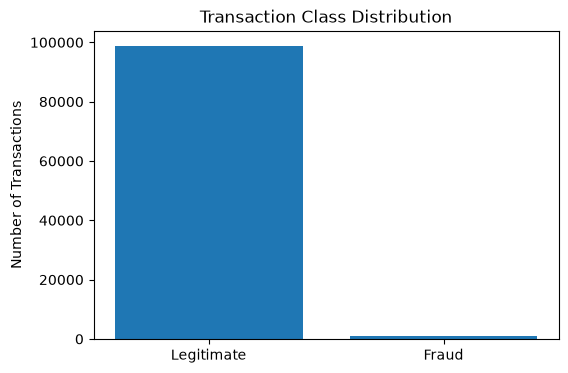

In [ ]:
import matplotlib.pyplot as plt

fraud_counts = df["is_fraud"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Legitimate", "Fraud"], fraud_counts.values)
plt.title("Transaction Class Distribution")
plt.ylabel("Number of Transactions")
plt.show()


In [ ]:
print(df["is_fraud"].value_counts())

print("\nFraud percentage:")
print(df["is_fraud"].value_counts(normalize=True) * 100)

is_fraud
0    98895
1     1105
Name: count, dtype: int64

Fraud percentage:
is_fraud
0    98.895
1     1.105
Name: proportion, dtype: float64


In [ ]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate transaction IDs:", df["transaction_id"].duplicated().sum())

Duplicate rows: 0
Duplicate transaction IDs: 0


In [ ]:
df.isnull().sum()

transaction_id               0
transaction_amount           0
transaction_hour             0
account_age_days             0
new_device                   0
location_mismatch            0
failed_attempts              0
transactions_last_10min      0
transactions_last_24h        0
previous_avg_amount          0
international_transaction    0
is_fraud                     0
dtype: int64

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   transaction_id             100000 non-null  str    
 1   transaction_amount         100000 non-null  float64
 2   transaction_hour           100000 non-null  int64  
 3   account_age_days           100000 non-null  int64  
 4   new_device                 100000 non-null  int64  
 5   location_mismatch          100000 non-null  int64  
 6   failed_attempts            100000 non-null  int64  
 7   transactions_last_10min    100000 non-null  int64  
 8   transactions_last_24h      100000 non-null  int64  
 9   previous_avg_amount        100000 non-null  float64
 10  international_transaction  100000 non-null  int64  
 11  is_fraud                   100000 non-null  int64  
dtypes: float64(2), int64(9), str(1)
memory usage: 10.3 MB


In [ ]:
print(df.columns.tolist())

['transaction_id', 'transaction_amount', 'transaction_hour', 'account_age_days', 'new_device', 'location_mismatch', 'failed_attempts', 'transactions_last_10min', 'transactions_last_24h', 'previous_avg_amount', 'international_transaction', 'is_fraud']


In [ ]:
df.head()

,transaction_id,transaction_amount,transaction_hour,account_age_days,new_device,location_mismatch,failed_attempts,transactions_last_10min,transactions_last_24h,previous_avg_amount,international_transaction,is_fraud
0,TXN_00000001,8375.27,17,165,0,0,0,0,0,2416.07,0,0
1,TXN_00000002,4468.06,16,1055,1,0,0,0,1,7837.86,0,0
2,TXN_00000003,1017.35,14,462,0,0,0,0,1,1248.76,0,0
3,TXN_00000004,228.71,11,321,0,0,0,0,3,287.63,0,0
4,TXN_00000005,4209.56,20,60,1,0,0,0,2,3632.74,0,0


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/transactions.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (100000, 12)
